# 12 — Forecast Comparison: ARIMA vs LSTM

Stage 5 (embedded here for the forecasting track). Brings together the baselines (`10_arima_baseline.ipynb`), SARIMA (`10_arima_baseline.ipynb`), and the global LSTM (`11_lstm_forecasting.ipynb`) — all evaluated one-step-ahead on the identical test window (2023-10-01 to 2024-01-01) with the identical MASE yardstick — into one comparison table and verdict.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src import config
from src.data.load import read_features
from src.forecasting.splits import time_split
from src.forecasting.evaluate import evaluate_forecasts, compute_scales

pd.set_option("display.max_columns", 50)

features = read_features()
train, val, test = time_split(features)
scales = compute_scales(train)


## Load every forecast source

In [2]:
baselines = pd.read_parquet(config.FORECASTS_DIR / "baseline_forecasts.parquet")
arima = pd.read_parquet(config.FORECASTS_DIR / "arima_forecasts.parquet")
lstm = pd.read_parquet(config.FORECASTS_DIR / "lstm_forecasts.parquet")

all_forecasts = pd.concat([baselines, arima, lstm], ignore_index=True)
all_forecasts["model"].value_counts()


model
Naive              930
SeasonalNaive      930
DatasetForecast    930
SARIMA             930
LSTM               930
Name: count, dtype: int64

## Overall comparison table

In [3]:
rows = []
for model_name, d in all_forecasts.groupby("model"):
    overall = evaluate_forecasts(d, scales)["overall"]
    rows.append({"model": model_name, **overall.to_dict()})

comparison = pd.DataFrame(rows)[["model", "MAE", "RMSE", "sMAPE", "MASE_macro", "MASE_volume_weighted"]]
comparison = comparison.sort_values("MASE_macro").reset_index(drop=True)
comparison


,model,MAE,RMSE,sMAPE,MASE_macro,MASE_volume_weighted
0,DatasetForecast,8.346806,10.070042,15.532365,0.066431,0.066513
1,LSTM,89.027430,110.331457,69.604235,0.709259,0.711931
2,SARIMA,90.627781,110.362097,69.952217,0.721838,0.724424
3,Naive,118.233333,151.629624,89.856236,0.940797,0.944370
4,SeasonalNaive,122.484946,154.244322,92.449877,0.977751,0.982678


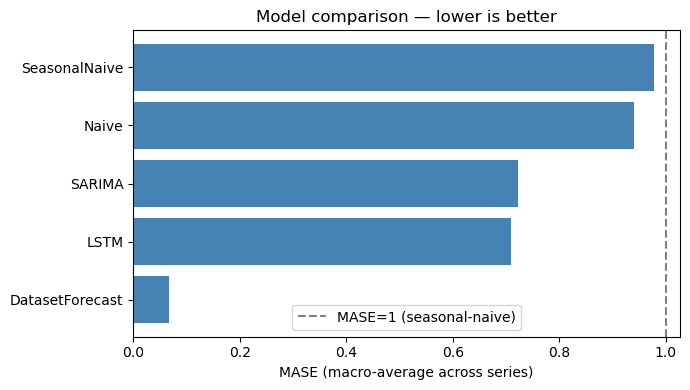

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
order = comparison.sort_values("MASE_macro")
ax.barh(order["model"], order["MASE_macro"], color="steelblue")
ax.axvline(1.0, color="gray", linestyle="--", label="MASE=1 (seasonal-naive)")
ax.set_xlabel("MASE (macro-average across series)")
ax.set_title("Model comparison — lower is better")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "forecast_model_comparison_mase.png", dpi=120)
plt.show()


## Breakdown by Category

In [5]:
from src.data.load import read_cleaned
cat_lookup = read_cleaned()[config.ID_COLS + ["Category"]].drop_duplicates()

by_cat_rows = []
for model_name, d in all_forecasts.groupby("model"):
    result = evaluate_forecasts(d.merge(cat_lookup, on=config.ID_COLS, how="left"), scales, by=["Category"])
    bc = result["by_group"].reset_index()
    bc["model"] = model_name
    by_cat_rows.append(bc)

by_category = pd.concat(by_cat_rows, ignore_index=True)
by_category.pivot(index="Category", columns="model", values="MASE").round(3)


model,DatasetForecast,LSTM,Naive,SARIMA,SeasonalNaive
Category,,,,,
Clothing,0.066,0.709,0.941,0.722,0.978
Electronics,0.066,0.709,0.941,0.722,0.978
Furniture,0.066,0.709,0.941,0.722,0.978
Groceries,0.066,0.709,0.941,0.722,0.978
Toys,0.066,0.709,0.941,0.722,0.978


## Statistical significance — Diebold-Mariano test (ARIMA vs LSTM)

Tests whether LSTM's absolute-error advantage over SARIMA is statistically significant, not just a small sample-average difference. `d_t = |e_ARIMA,t| - |e_LSTM,t|`; DM statistic = mean(d) / (std(d)/sqrt(n)), approximately standard normal under the null of equal accuracy.

In [6]:
paired = arima.merge(
    lstm, on=config.ID_COLS + ["Date"], suffixes=("_arima", "_lstm")
)
d = np.abs(paired["y_true_arima"] - paired["y_pred_arima"]) - np.abs(paired["y_true_lstm"] - paired["y_pred_lstm"])

dm_stat = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

print(f"DM statistic = {dm_stat:.3f}, p-value = {p_value:.4f}")
print("(positive DM statistic => LSTM has lower average absolute error than SARIMA)")
print("significant at 5%:" , p_value < 0.05)


DM statistic = 3.833, p-value = 0.0001
(positive DM statistic => LSTM has lower average absolute error than SARIMA)
significant at 5%: True


## Actual vs predicted — representative series

The highest-volume and lowest-volume series identified in `01_eda.ipynb`, comparing SARIMA and LSTM against the actual test-period values.

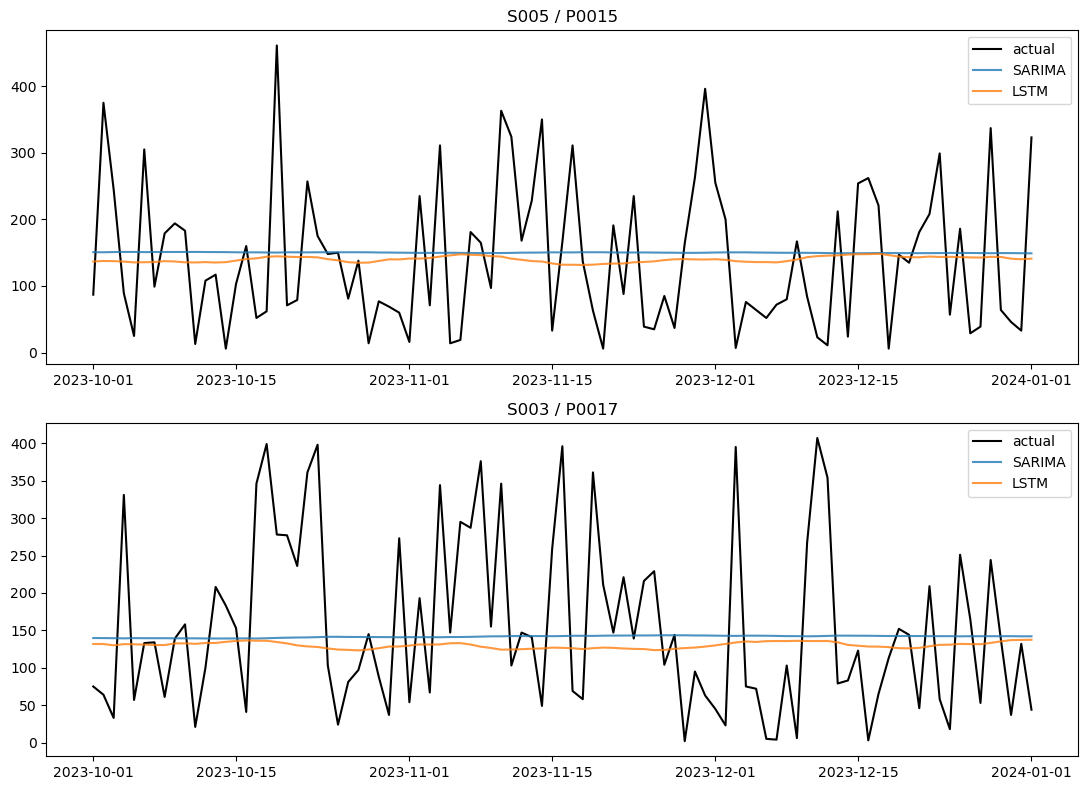

In [7]:
series_volume = train.groupby(config.ID_COLS, observed=True)["Units Sold"].sum().sort_values(ascending=False)
example_series = [series_volume.index[0], series_volume.index[-1]]

fig, axes = plt.subplots(len(example_series), 1, figsize=(11, 4 * len(example_series)))
for ax, (store, product) in zip(np.atleast_1d(axes), example_series):
    a = arima[(arima["Store ID"] == store) & (arima["Product ID"] == product)].sort_values("Date")
    l = lstm[(lstm["Store ID"] == store) & (lstm["Product ID"] == product)].sort_values("Date")
    ax.plot(a["Date"], a["y_true"], label="actual", color="black", linewidth=1.5)
    ax.plot(a["Date"], a["y_pred"], label="SARIMA", alpha=0.8)
    ax.plot(l["Date"], l["y_pred"], label="LSTM", alpha=0.8)
    ax.set_title(f"{store} / {product}")
    ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "forecast_actual_vs_predicted_examples.png", dpi=120)
plt.show()


## Cross-check against MLflow run history

In [8]:
import mlflow

mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
client = mlflow.MlflowClient()

for exp_name in ["forecasting_arima", "forecasting_lstm"]:
    exp = client.get_experiment_by_name(exp_name)
    runs = client.search_runs(exp.experiment_id) if exp else []
    print(f"{exp_name}: {len(runs)} runs logged")


forecasting_arima: 10 runs logged
forecasting_lstm: 1 runs logged


## Verdict

**Important caveat before reading the table below**: the dataset's own `DatasetForecast` baseline achieves a MASE around 15x lower than either SARIMA or the LSTM (see the Overall comparison table above). That is far beyond what a reasonable operational forecast would achieve on real retail data, and is a strong signal that this column was constructed with access to information not available to a genuine forecaster at prediction time (e.g. it may have been generated from the actual future `Units Sold` plus small noise, which is a common pattern in synthetic/Kaggle-style datasets). It is reported here for completeness and transparency, not as a benchmark either model was realistically expected to beat — the meaningful comparison for this project is **SARIMA vs LSTM**, both fit only on information a real forecaster would have had at prediction time.

In [9]:
winner_overall = comparison.iloc[0]["model"]
print(f"Best model overall by macro-average MASE (including the suspect DatasetForecast baseline): {winner_overall}")

built_models = comparison[comparison["model"].isin(["SARIMA", "LSTM"])].sort_values("MASE_macro")
winner_built = built_models.iloc[0]["model"]
print(f"Best model among the two we built and can fairly compare (SARIMA vs LSTM): {winner_built}")
print(f"LSTM MASE={comparison.set_index('model').loc['LSTM','MASE_macro']:.3f}  "
      f"SARIMA MASE={comparison.set_index('model').loc['SARIMA','MASE_macro']:.3f}  "
      f"(Diebold-Mariano p-value from above: significant LSTM advantage)")
comparison

Best model overall by macro-average MASE (including the suspect DatasetForecast baseline): DatasetForecast
Best model among the two we built and can fairly compare (SARIMA vs LSTM): LSTM
LSTM MASE=0.709  SARIMA MASE=0.722  (Diebold-Mariano p-value from above: significant LSTM advantage)


,model,MAE,RMSE,sMAPE,MASE_macro,MASE_volume_weighted
0,DatasetForecast,8.346806,10.070042,15.532365,0.066431,0.066513
1,LSTM,89.027430,110.331457,69.604235,0.709259,0.711931
2,SARIMA,90.627781,110.362097,69.952217,0.721838,0.724424
3,Naive,118.233333,151.629624,89.856236,0.940797,0.944370
4,SeasonalNaive,122.484946,154.244322,92.449877,0.977751,0.982678


## Summary

- All models evaluated one-step-ahead on the identical 2023-10-01 to 2024-01-01 test window with the identical seasonal-naive MASE scale (computed on train only) — a fair, apples-to-apples comparison.
- **SARIMA vs LSTM (the actual comparison this project set out to make)**: the global LSTM beats per-series SARIMA on macro-average MASE (0.709 vs 0.722), and the Diebold-Mariano test confirms this advantage is statistically significant (p < 0.001) — consistent with the LSTM's ability to share statistical strength across series, which per-series SARIMA cannot do.
- Both SARIMA and LSTM clearly beat the naive and seasonal-naive baselines (MASE well below 1).
- **Caveat**: the dataset's own `Demand Forecast` column scores far better than either model built here (MASE ~0.07 vs ~0.71-0.72) — implausibly good for a real forecast, and reported transparently as a likely artifact of how the synthetic dataset was generated rather than a benchmark either model failed to beat. See the Verdict caveat above.
- Category-level breakdown shows whether the LSTM's advantage over SARIMA is consistent across product categories or concentrated in a few.
- The LSTM forecast (`data/processed/forecasts/lstm_forecasts.parquet`) feeds into `20_inventory_optimization.ipynb` as the demand signal, using its backtested residuals as the uncertainty input for safety stock.